In [477]:
#CHURN ANALYSIS


In [478]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3



In [479]:
#importing database/data

In [480]:
conn=sqlite3.connect("customer_churn.db")

sql_query=""" 
        SELECT name
        FROM sqlite_master
        WHERE type='table'

"""

tables=pd.read_sql(sql_query,conn)

# create dataframe for each table
#globals() Creates a global dataframe variable named df_<table_name> and stores the current table's data in it.
#here f is formateed string literal so in place of curly brackets the variable value is replaces


for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

conn.close()


Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [481]:
#printing table names and column names

conn=sqlite3.connect("customer_churn.db")
for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    #getting column information
    columns_query=f"PRAGMA table_info({table_name});"
    columns=pd.read_sql(columns_query,conn)
    print("Columns: ")
    print(columns['name'].tolist())

#close connection
conn.close()


Table Name: db_customer
Columns: 
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns: 
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns: 
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [482]:
#DATA CLEANING

In [483]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [484]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,NaN,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,NaN,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,NaN,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,NaN,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,NaN,None


In [485]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 2.5+ KB


In [486]:
# a.Rename column - name column
# b.Drop columns - interest and pincode columns
# c.Change Datatype - dob
# d.data standardization - gender
# e.fix missing values - country column



In [487]:
# a.Rename column - name column

df_db_customer=df_db_customer.rename(columns={'name' : 'customer_name'})

In [488]:
df_db_customer.head()

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [489]:
# b.Drop columns - interest and pincode columns

#there are many ways to do this

df_db_customer=df_db_customer.drop(df_db_customer.columns[-2:],axis=1)
#axis=1 is used for columns and axis =0 for rows

#df_db_customer.drop(df_db_customer.columns[6:],axis=1)
#here doing this after column 6 everything will be dropped



In [490]:
# c.Change Datatype - dob
df_db_customer['dob']=pd.to_datetime(df_db_customer['dob'])
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [491]:
# d.data standardization - gender
# we want only male and female values by standardisation

#df_db_customer['gender'].unique()
df_db_customer['gender']=df_db_customer['gender'].replace({'Men': 'Male','Women':'Female'})
df_db_customer



,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [492]:
# e.fix missing values - country column
#na means null

df_db_customer[df_db_customer['country'].isna()]
#this will just show the country which has NaN

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [493]:
state_country_mapping = (
    df_db_customer
    .dropna(subset=['country'])
    .set_index('state')['country']
    .to_dict()
)

df_db_customer['country'] = df_db_customer['country'].fillna(
    df_db_customer['state'].map(state_country_mapping)
)

df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,India,Delhi,Female,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,Nepal,Kathmandu,Female,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [494]:
#Now moving onto the subscription table



In [495]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [496]:
df_db_subscription.info()
#note that cltv is cutomer life time value
#one prob noted here is taht all the date type columsn here are objects i need to fix them

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 3.1 KB


In [497]:
#we can use the .apply method here to change things in many columns together

In [498]:
date_col=['subscription_start_date','renewal_date','cancellation_date']

df_db_subscription[date_col]=df_db_subscription[date_col].apply(pd.to_datetime)

df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 2.7 KB


In [499]:
#Now Doing Data Cleaning of Customer Support Table

df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [500]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 895.0+ bytes


In [501]:
#we will delete last 2 columns no need

df_db_support.drop(columns=['col_1','comment'],inplace=True)

In [502]:
#we will make complaint_date column to datetime

df_db_support['complaint_date']=pd.to_datetime(df_db_support['complaint_date'])

In [503]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 519.0 bytes


In [504]:
# 3 . Feature Engineering and Data Analysis



In [505]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [506]:
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

#here where method is used it sees cancellation date
#if there is a cancellation date that means the user has cancelled their subscription so churn_flag column will store 1 if not cancelled then 0

In [507]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [508]:
#our main table is subscription table and using it i will join other tables to it

#for taht we will use merge function


In [509]:
#merge df



In [510]:
df.shape

(9, 4)

In [511]:
# Merge subscription and customer
df = df_db_subscription.merge(
    df_db_customer,
    on='customerid',
    how='left'
)

# Merge the result with support
df = df.merge(
    df_db_support,
    on='customerid',
    how='left'
)

print(df.shape)
df.head()

(23, 20)


,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN


In [512]:
print(df.columns.tolist())

['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score', 'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob', 'complaint_date', 'escalations', 'csat_score']


In [513]:
df_db_subscription['customerid'].nunique()

21

In [514]:
df_db_support['customerid'].nunique()

7

In [515]:
df_db_support['customerid'].size

9

In [516]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30


In [517]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [518]:
df_db_support['complaint_count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [519]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [520]:
df_db_support=df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep='last')

In [521]:
print(df.columns.tolist())

['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score', 'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob', 'complaint_date', 'escalations', 'csat_score']


In [522]:
print(df_db_subscription.columns.tolist())
print(df_db_customer.columns.tolist())
print(df_db_support.columns.tolist())

['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score', 'churn_flag']
['customerid', 'customer_name', 'country', 'state', 'gender', 'dob']
['customerid', 'complaint_date', 'escalations', 'csat_score', 'complaint_count']


In [523]:
df.to_csv('exported_churn_data.csv',index='false')

In [524]:
#Data Analyis

In [525]:
#1. Churn Rate

In [526]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score'],
      dtype='str')

In [527]:
#customer attrition or the rate at which users stop using a company's service
churn_rate=df['churn_flag'].mean() * 100
print("Churn Rate = ",round(churn_rate,2), "%")

Churn Rate =  34.78 %


In [528]:
#2 Retention Rate
#Retention generally means the continued possession, use, or control of something
retention_rate=100-churn_rate
print("Retention Rate = ",round(retention_rate,2), "%")


Retention Rate =  65.22 %


In [529]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0


In [530]:
#Seeing Which Plan Type of Users are involved in the Churn Rate



In [531]:
# 3. Churn By Plan Type


In [532]:
churn_by_plan=df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct')

print( churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           66.67
1   Premium           25.00
2  Standard           22.22


In [533]:
# The max Churn Rate is by Basic Plan Type



In [534]:
#4a. Churn By State
churn_by_state=df.groupby('state')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct')

print( churn_by_state)


           state  churn_rate_pct
0          Delhi           25.00
1      Karnataka          100.00
2      Kathmandu            0.00
3    Maharashtra            0.00
4      Meghalaya           66.67
5       Nagaland            0.00
6      Rajasthan            0.00
7      Telangana           66.67
8  Uttar Pradesh            0.00


In [535]:
#4b. Churn By Subscription Type

churn_by_subscription_type=df.groupby('subscription_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct')

print( churn_by_subscription_type)

  subscription_type  churn_rate_pct
0           Organic            0.00
1              Paid           28.57
2          Refferal           85.71


In [536]:
#5. ARPU - Average Revenue Per User

arpu=df['monthly_charges'].mean()
print("ARPU = ",round(arpu,2))

ARPU =  18.51


In [537]:
from datetime import datetime

df['dob'] = pd.to_datetime(df['dob'])

today = datetime.today()

df['age'] = (
    today.year
    - df['dob'].dt.year
    - (
        (today.month < df['dob'].dt.month)
        | (
            (today.month == df['dob'].dt.month)
            & (today.day < df['dob'].dt.day)
        )
    )
)

df[['customer_name', 'dob', 'age']].head()

,customer_name,dob,age
0,keshav,1982-04-12,44
1,raghav,1995-11-23,30
2,raghav,1995-11-23,30
3,lalita,1978-02-15,48
4,mohan,2001-08-30,24


In [538]:
#6. Average Customer Tenure
# counting The number of days user has used our service: cancellation date else current date
today=pd.Timestamp.today()

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(), (df['cancellation_date']-df['subscription_start_date']).dt.days,(today-df['subscription_start_date']).dt.days


)

avg_tenure=df['tenure_days'].mean()
print("Average Tenure Days = ",round(avg_tenure),0)

Average Tenure Days =  1450 0


In [539]:
# 7. Revenue at Risk - Revenue Lost From Churned Users
#The .loc[] function in pandas is used to select rows and columns by their labels (names).



revenue_at_risk=df.loc[df['churn_flag']==1, 'monthly_charges'].sum() 
print("Revenue At Risk =  Rs. ",revenue_at_risk,"K")

Revenue At Risk =  Rs.  103.91999999999999 K


In [540]:
# 8. Escalation Rate

escalation_rate=(df['escalations']=='Y').mean()*100
print("Escalation Rate = ",round(escalation_rate,2),"%")

Escalation Rate =  21.74 %


In [541]:
#9. Average Complaint Rate Per User

avg_complaints=df['complaint_count'].sum() / df['customer_id'].nunique()

KeyError: 'complaint_count'

In [ ]:
#10. Correlation:  Escalation Vs Churn
#when using more than one column when filtering use double square brackets




df['escalations']=np.where(df['escalations']=='Y', 1,0) #encoding string to int type

corr_df=df[['escalations','churn_flag']].dropna()

correlation= corr_df['escalations'].corr(df['churn_flag'])

print("Correlation Between Escalation and Churn =  ",correlation,"%")



c:\Users\ayesh\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\ayesh\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


np.float64(nan)

In [ ]:
#Churn Risk - Create a Column Using Existing Tool
conditions = [
    (df['churn_score'] < 50),
    ((df['churn_score'] >= 50) & (df['churn_score'] < 70)),
    (df['churn_score'] >= 70)
]

choices = ['low', 'medium', 'high']

df['churn_risk'] = np.select(
    conditions,
    choices,
    default='Unknown'
)

df[['churn_score', 'churn_risk']].head(10)

,churn_score,churn_risk
0,12,low
1,91,high
2,91,high
3,34,low
4,8,low
5,88,high
6,22,low
7,79,high
8,5,low
9,34,low


In [ ]:
#4. Data Visualization Using MatPlotLib

In [ ]:
df_visual=df.copy()
# making sure we have retained the copy of the database

In [ ]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'age', 'tenure_days',
       'churn_risk'],
      dtype='str')

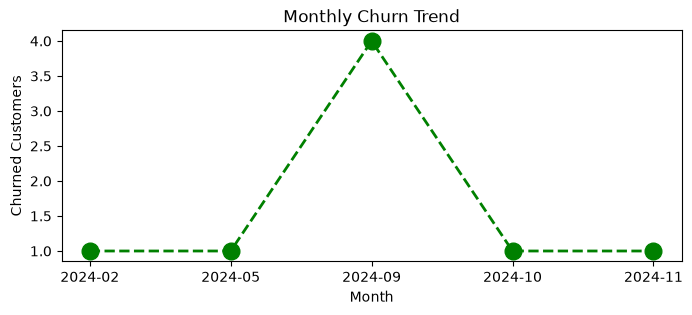

In [ ]:
# 4.1 : Monthly Churn Trend(Time Series KPI)

# Trend is related to time so time will be included here also

df_visual['cancellation_month']=df_visual['cancellation_date'].dt.to_period('M')

#to_period: if we keep 'M' inside it gives us Month, if 'D' it gives date and if 'Y' it gives year
#h for hourly and min for minutes

churn_trend=df_visual[df_visual['churn_flag']==1].groupby('cancellation_month').size()

plt.figure(figsize=(8,3))

plt.plot(churn_trend.index.astype(str),churn_trend.values,color='green',marker='o',linestyle='dashed',linewidth=2,markersize=12)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

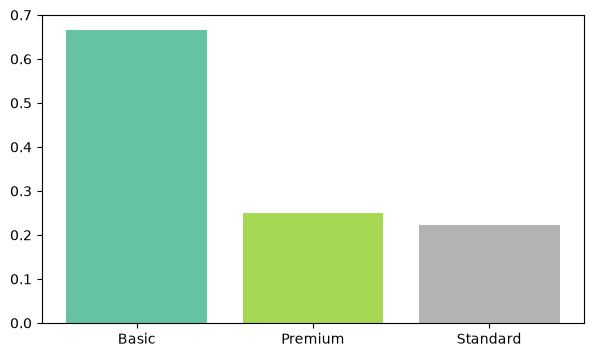

In [ ]:
#4.2 Churn By Plan Type

churn_plan=df_visual.groupby('plan_type')['churn_flag'].mean()
#colors=[red,yellow,green]
colors=plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.figure(figsize=(7,4))

plt.bar(churn_plan.index,churn_plan.values,color=colors)

plt.show()


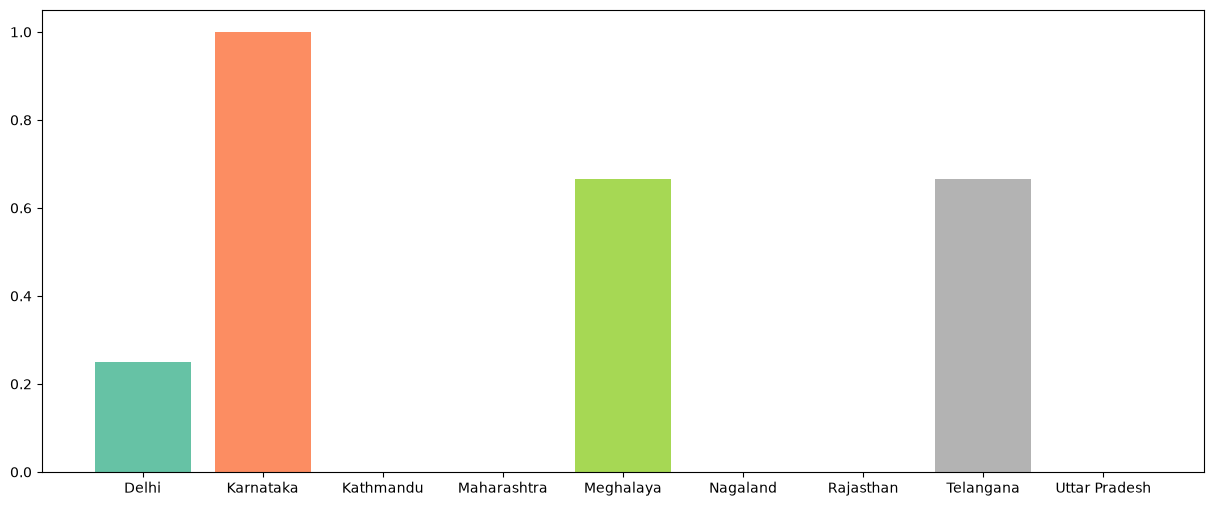

In [ ]:
#4.3 Churn By States

churn_plan=df_visual.groupby('state')['churn_flag'].mean()
#colors=[red,yellow,green]
colors=plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.figure(figsize=(15,6))

plt.bar(churn_plan.index,churn_plan.values,color=colors)

plt.show()


In [ ]:
# Data Visualization Using Seaborn


In [ ]:
#encoding
#converting str to numeric values to find correlation between features

df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'age', 'tenure_days',
       'churn_risk', 'cancellation_month'],
      dtype='str')

In [ ]:
#incorrect method of encoding as numbers are not assigned on priority

df_encoded=df_visual[['plan_type', 'contract_type','churn_score','churn_flag','churn_risk','escalations']]

categorical_cols=['plan_type','contract_type','churn_risk','escalations']

for col in categorical_cols:
    df_encoded[col]=df_encoded[col].astype('category').cat.codes

    

In [ ]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,1,NaN
1,1,0,91,1,0,N
2,1,0,91,1,0,Y
3,0,1,34,0,1,NaN
4,1,0,8,0,1,NaN


<Axes: >

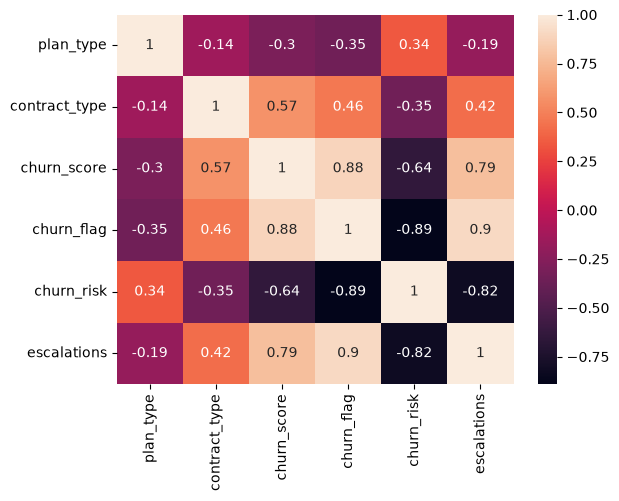

In [ ]:
# Heatmap (correlation Matrix)

#heatmap and correlation can only be done for numeric values


sns.heatmap(df_encoded.corr(),annot=True)

In [ ]:
#correct method of encoding based on priority
order_mappings = {
    'plan_type': ['Basic', 'Standard', 'Premium'],
    'contract_type': ['Monthly', 'Annual'],
    'churn_risk': ['low', 'medium', 'high']
}

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(
        df_encoded[col],
        categories=order,
        ordered=True
    )


In [ ]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,NaN
1,Premium,Annual,91,1,high,N
2,Premium,Annual,91,1,high,Y
3,Basic,Monthly,34,0,low,NaN
4,Premium,Annual,8,0,low,NaN


In [ ]:
sns.heatmap(df_encoded.corr(),annot=True)

ValueError: could not convert string to float: 'Standard'

In [ ]:
print(df_encoded.dtypes)

plan_type        category
contract_type    category
churn_score         int64
churn_flag          int64
churn_risk       category
escalations           str
dtype: object


In [ ]:
print(df_encoded['escalations'].unique())
print(df_encoded['escalations'].dtype)

<ArrowStringArray>
[nan, 'N', 'Y']
Length: 3, dtype: str
str


In [ ]:
df_encoded['escalations'] = (
    df_encoded['escalations']
    .map({'N': 0, 'Y': 1})
    .fillna(0)
    .astype(int)
)

In [ ]:
print(df_encoded.dtypes)

plan_type        category
contract_type    category
churn_score         int64
churn_flag          int64
churn_risk       category
escalations         int64
dtype: object


In [542]:
for col in ['plan_type', 'contract_type', 'churn_risk']:
    df_encoded[col] = df_encoded[col].cat.codes

In [543]:
print(df_encoded.dtypes)

plan_type         int8
contract_type     int8
churn_score      int64
churn_flag       int64
churn_risk        int8
escalations      int64
dtype: object


<Axes: >

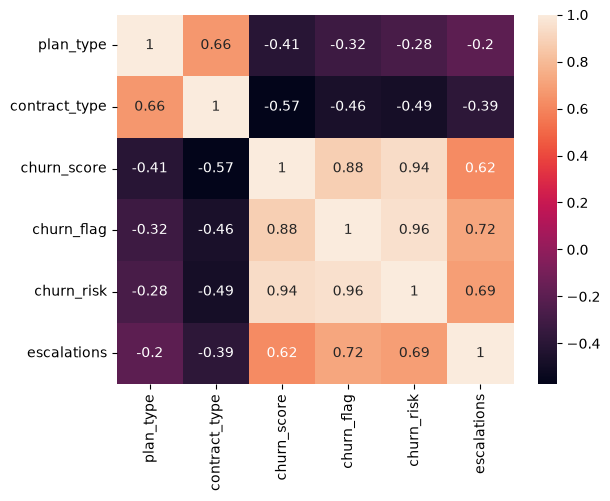

In [544]:
sns.heatmap(df_encoded.corr(),annot=True)

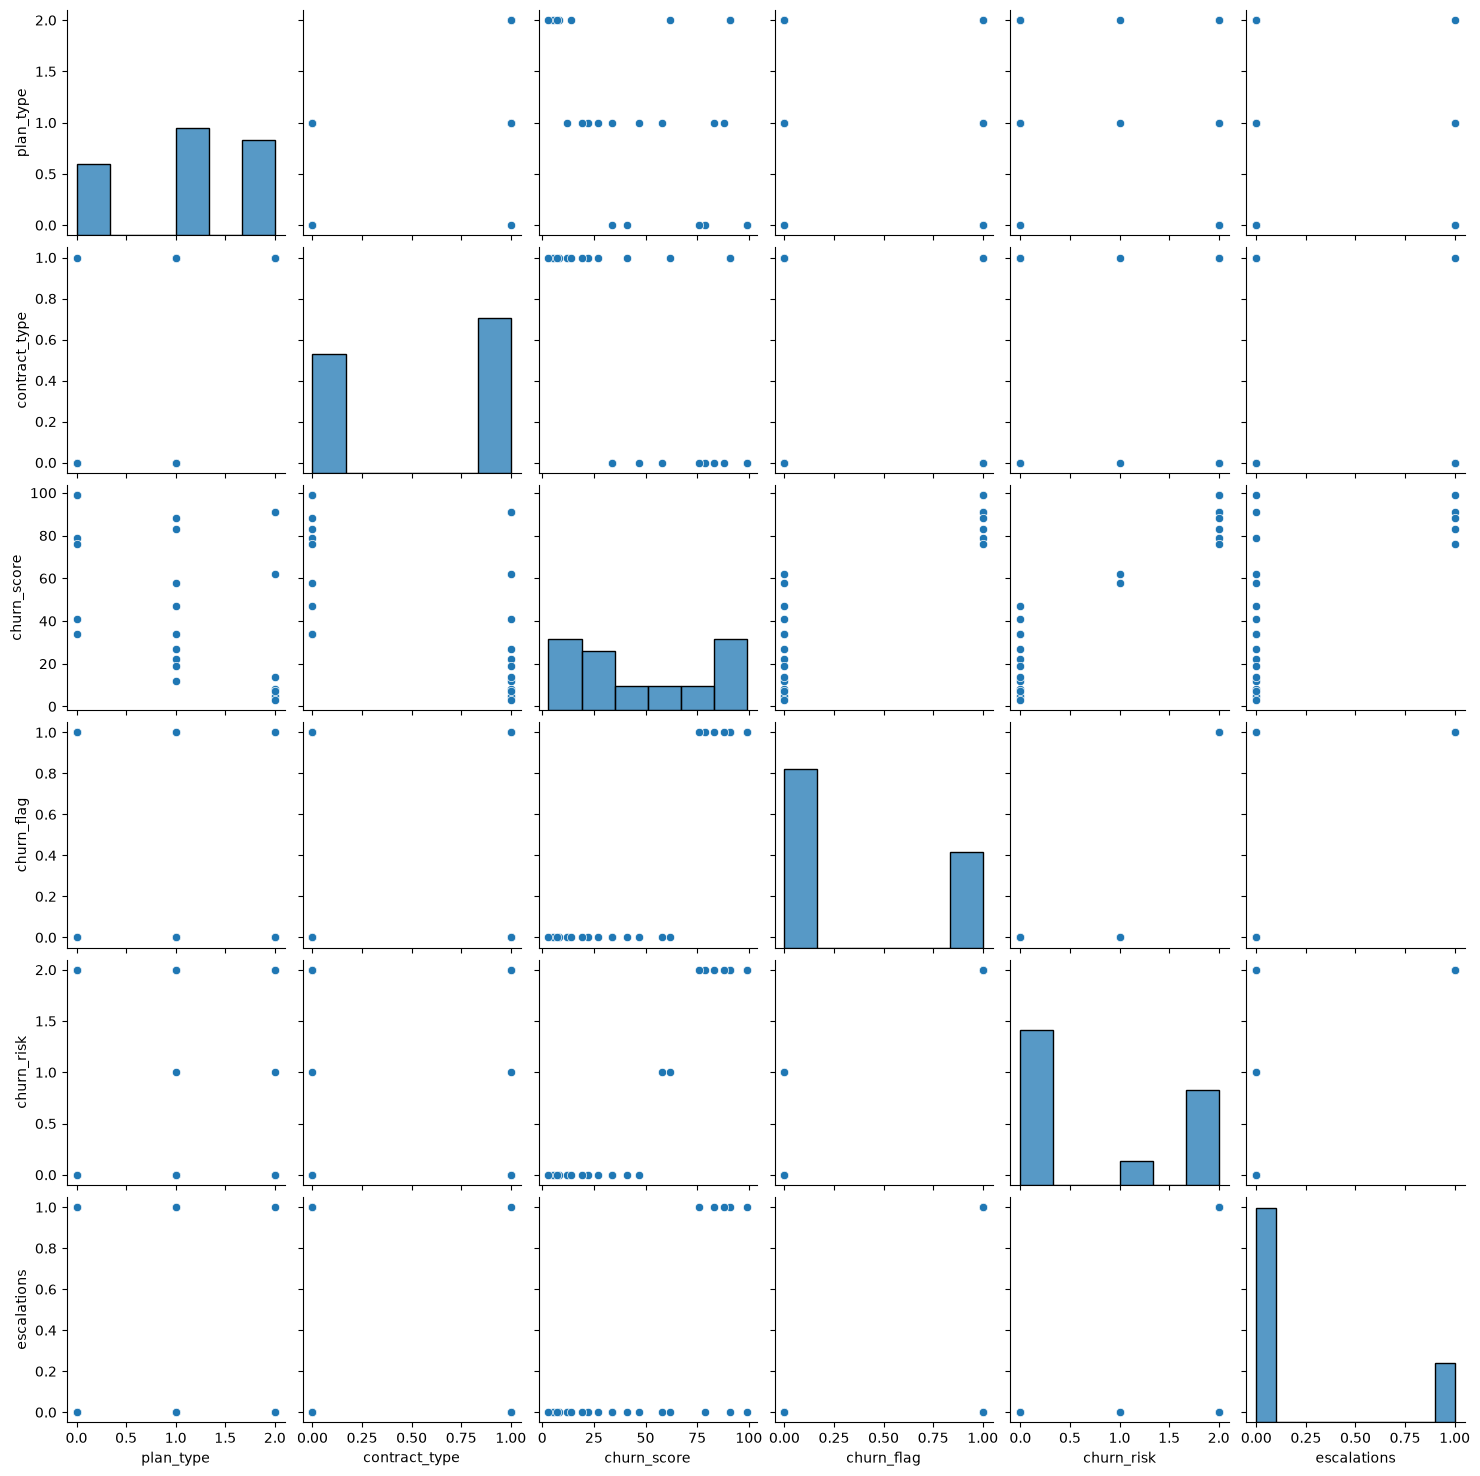

In [545]:
# pair plot

sns.pairplot(df_encoded)

In [546]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'age', 'tenure_days',
       'churn_risk', 'cancellation_month'],
      dtype='str')

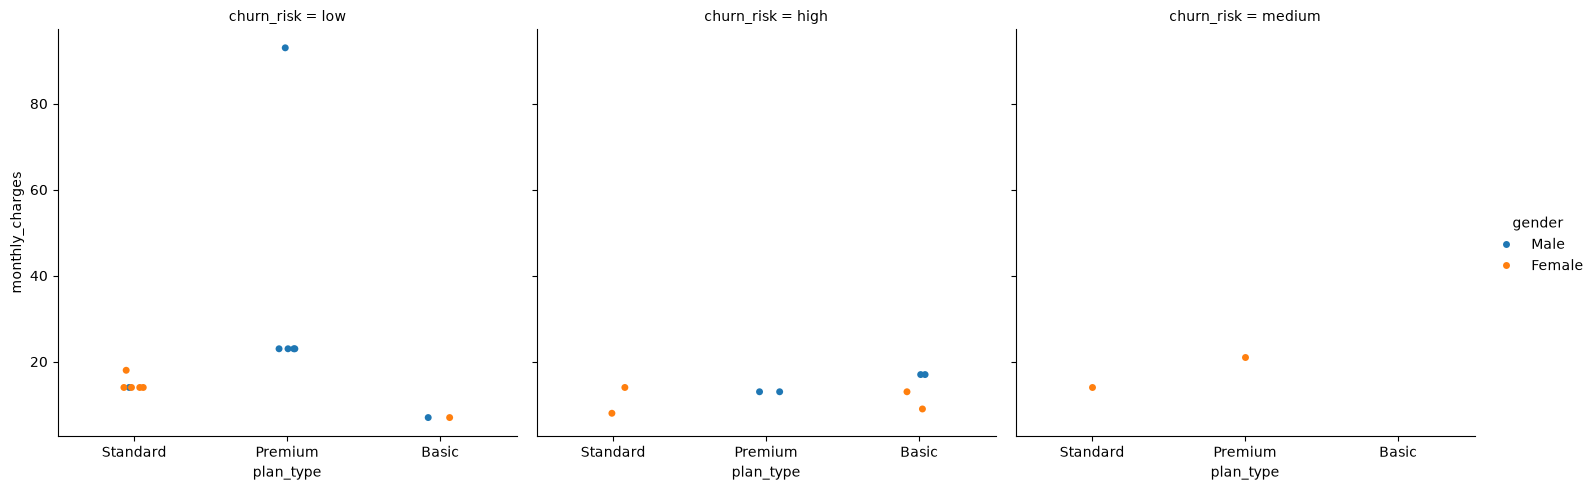

In [548]:
# catplt / Facegrid plot - multi-dimension comparision


sns.catplot(data=df_visual,x='plan_type',y='monthly_charges',hue='gender',col='churn_risk')

In [ ]:
# Pivot Table 



In [552]:
pd.pivot_table(df_visual,index='plan_type',values=['monthly_charges','customerid','churn_flag'],aggfunc={'monthly_charges':'sum','customerid':'nunique','churn_flag':'mean'})

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.666667,5,69.94
Premium,0.250000,7,231.92
Standard,0.222222,9,123.91


In [ ]:
# Working With SQL in python (pandas)


In [557]:
#create database in SQL

#SQL data types (one-line definitions):
#to comment multiple lines in python ctrl + /

# INT – Stores whole numbers.
# FLOAT – Stores approximate decimal numbers.
# DECIMAL – Stores exact decimal numbers.
# CHAR – Stores fixed-length text.
# VARCHAR – Stores variable-length text.
# TEXT – Stores long text.
# DATE – Stores dates (YYYY-MM-DD).
# TIME – Stores time (HH:MM:SS).
# DATETIME – Stores both date and time.
# TIMESTAMP – Stores date and time, often with automatic updates.
# BOOLEAN (BOOL) – Stores TRUE or FALSE.
# BLOB – Stores binary data such as images or files.

conn = sqlite3.connect('test_database.sqlite')

#table details

conn.execute("CREATE TABLE IF NOT EXISTS users (first_name TEXT,country TEXT, budget INTEGER )")

#commit and save

conn.commit()

In [564]:
# inserting Data
# the best practice to insert data while using execute in in triple quotes

cursor = conn.cursor()

cursor.execute("""
INSERT INTO users VALUES
('Ayesha', 'Pakistan', 5000),
('Nabiha', 'Canada', 9000),
('Mariam','Nepal',5690)
""")

conn.commit()

print("Data Inserted Successfully")

Data Inserted Successfully


In [565]:
#check inserted in table

conn=sqlite3.connect('test_database.sqlite')
query=""" SELECT * FROM users """
df_results=pd.read_sql(query,conn)

df_results.head()

,first_name,country,budget
0,Ayesha,Pakistan,5000
1,Nabiha,Canada,9000
2,Ayesha,Pakistan,5000
3,Nabiha,Canada,9000
4,Mariam,Nepal,5690


In [566]:
#aggregation

query = """ 

        SELECT country, SUM(budget) as total_budget
        FROM users
        GROUP BY country

"""

df_agg=pd.read_sql(query,conn)
df_agg

,country,total_budget
0,Canada,27000
1,Nepal,11380
2,Pakistan,15000


In [ ]:
# Always Close the connection with db once the task is over

conn.close()